In [101]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
print('All packages loaded')

All packages loaded


# Introduction
In this notebook we calibrate a number of models on EURIBOR daily data, with the aim to compare their performance with a simple Random Walk model. The models that we are going to use can be categorized in 2 different field of study:
1. **Mathematical Finance**: Vasicek, CIR
2. **Machine Learning**: ARMA, Random Forest, LSTM

For each model we perform a **rolling window** approach, with a number of **30** observations for each step, and forecast: 
*1-day, 1_week, 1_month, 3_months ahead*. 

# Import EURIBOR data
First step is importing the full dataset, clean it, and keep only the time series we are working on.

In [102]:
df = pd.read_excel('EURIBOR.xlsx')
df.head()

,Date,1 week,1 month,3 month,6 month,12 month
0,2006-04-03,2.614,2.647,2.818,2.992,3.254
1,2006-04-04,2.615,2.649,2.822,3.002,3.264
2,2006-04-05,2.635,2.651,2.824,3.006,3.260
3,2006-04-06,2.653,2.654,2.831,3.007,3.260
4,2006-04-07,2.643,2.641,2.764,2.915,3.159


Let's set the date as index and keep the 1 week maturity rates only, which are the best proxy for **short term rates**. This is important as the Mathematical Finance models we use, have been theoretically built to model short term rates in continuous time. 

In [103]:
df.index = df.Date
euribor_ir = df.iloc[:, 1] 
euribor_ir.head()

Date
2006-04-03    2.614
2006-04-04    2.615
2006-04-05    2.635
2006-04-06    2.653
2006-04-07    2.643
Name: 1 week, dtype: float64

# Random Walk 
This simple model can be mathematically expressed as follows:

$i_{t+\delta t} = i_{t} + \epsilon$

Where $\epsilon$ is a disturbance term with zero mean. 
This allows us to employ the **Random Walk** as a straightforward benchmark, where the optimal prediction for rates at time $t+1$ is merely the rates at time $t$. In essence, our time series is inherently unpredictable, as there is no additional information that can be harnessed for forecasting purposes. 

***RIVEDERE TUTTO A PARTIRE DA QUA QUANDO PARTIAMO CON IL CONFRONTO DI MODELLI !!!!!!!!!!!!!!***

In [104]:
# create data frames where I'll put my predictions
rw_1d = pd.Series(index=euribor_ir.index, dtype=float)
rw_7d = pd.Series(index=euribor_ir.index, dtype=float)
rw_30d = pd.Series(index=euribor_ir.index, dtype=float)
rw_90d = pd.Series(index=euribor_ir.index, dtype=float)

# Store the results in a single df
rw_pred = pd.DataFrame()
rw_pred['1d']=rw_1d
rw_pred['7d']=rw_7d
rw_pred['30d']=rw_30d
rw_pred['90d']=rw_90d

# Fill the Series
i = 0
for step_ahead in (1, 7, 30, 90):
    rw_pred.iloc[:, i] = euribor_ir.shift(step_ahead)
    i += 1

# show results
rw_pred.head()

,1d,7d,30d,90d
Date,,,,
2006-04-03,NaN,NaN,NaN,NaN
2006-04-04,2.614,NaN,NaN,NaN
2006-04-05,2.615,NaN,NaN,NaN
2006-04-06,2.635,NaN,NaN,NaN
2006-04-07,2.653,NaN,NaN,NaN


In [105]:
df1 = pd.merge(euribor_ir, rw_pred, on='Date', how='left')
df1.head()

,1 week,1d,7d,30d,90d
Date,,,,,
2006-04-03,2.614,NaN,NaN,NaN,NaN
2006-04-04,2.615,2.614,NaN,NaN,NaN
2006-04-05,2.635,2.615,NaN,NaN,NaN
2006-04-06,2.653,2.635,NaN,NaN,NaN
2006-04-07,2.643,2.653,NaN,NaN,NaN


In [106]:
# let's remove all the rows with NAs, which will be the 3 months used for calibrating the next models
df1 = df1.dropna()
df1.head()

,1 week,1d,7d,30d,90d
Date,,,,,
2006-08-10,3.092,3.092,2.835,2.855,2.614
2006-08-11,3.091,3.092,2.854,2.846,2.615
2006-08-14,3.091,3.091,2.997,2.840,2.635
2006-08-15,3.091,3.091,3.038,2.832,2.653
2006-08-16,3.092,3.091,3.088,2.823,2.643


<Axes: xlabel='Date'>

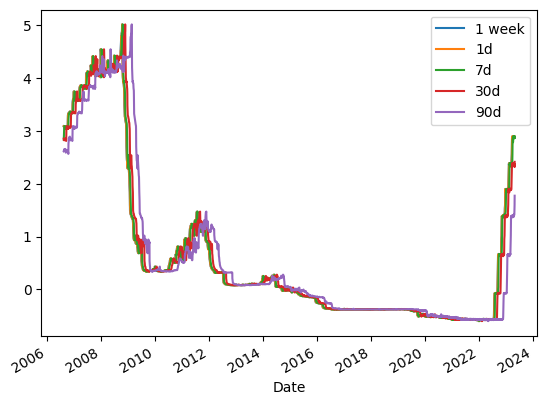

In [107]:
df1.iloc[:, 0:].plot()

THIS DF IS ONLY FOR ILLUSTRATIVE PURPOSES. BUT THE NEXT OBJECTIVE WILL BE TO HAVE A DF FOR EACH TIME FRAME AHEAD ESTIMATES WITH THE DIFFERENT MODELS. NOT A DATAFRAME FOR EACH MODEL AND DIFFERENT TIME FRAME

# Vasicek Model

First step to calibrate the Vasicek model is to create a dataset with 2 columns: one for the the $r_{t+\delta t}$ and another for $r_{t}$.
In our case we have to add another column which is the daily rates shifted by 1.

In [108]:
df = euribor_ir.copy()
df = pd.merge(df, euribor_ir.shift(1), on='Date', how='left')
df.columns = ['rates t', 'rates t-1']
df = df.dropna()
df.head()

,rates t,rates t-1
Date,,
2006-04-04,2.615,2.614
2006-04-05,2.635,2.615
2006-04-06,2.653,2.635
2006-04-07,2.643,2.653
2006-04-10,2.630,2.643


## Test with 30 observations
The next step is running a regression. Let's start by keeping 30 days and working with that. The objective is to make sure that the calibrated parameters make sense, in particular $\theta$ has to be coherent with the data, and that Monte Carlo predictions matches with the analytical ones.

In [109]:
# keep 30 days to test the algo
trial = df.iloc[:30, :]

# split y and X
y = trial[['rates t']]
X = trial[['rates t-1']]

# Build the model
model = LinearRegression()
model.fit(X, y)

# Get the estimated parameters and dt
intercept = model.intercept_  # Intercept (bias)
slope = model.coef_[0]        # Slope (coefficients)
dt = 1/252                    # since yield are in annual term

# Calculate the predicted values (y_hat) and the residuals
y_hat = model.predict(X)
residuals = y - y_hat

# get the parameter of interest for Vasicek
k = (1-intercept)/dt
theta = slope / (1-intercept)
sigma = np.std(residuals)/dt

# see the calibrated model
print(f'The calibrated Vasicek model is dr = {k}({theta}-r)+{sigma.values[0]}dW')

"""
################## SIMULATE THE MODEL 
# Initial interest rate
r0 = prova.iloc[-1, 0]

# Number of time steps
n_steps = 90

# Initialize arrays to store interest rate paths
interest_rates = np.zeros(n_steps+1)
interest_rates[0] = r0

# Simulate future interest rate path using Euler's method
for i in range(n_steps):
        dr = k * (theta - interest_rates[i]) * dt + sigma*np.sqrt(dt) * np.random.normal(0,1)
        interest_rates[i+1] = interest_rates[i] + dr

# Time steps
t = np.arange(n_steps+1)

print(f'my theta is {theta} and my initial rate is {r0}')
"""

The calibrated Vasicek model is dr = [58.53571009]([3.04780934]-r)+2.720867746272264dW


"\n################## SIMULATE THE MODEL \n# Initial interest rate\nr0 = prova.iloc[-1, 0]\n\n# Number of time steps\nn_steps = 90\n\n# Initialize arrays to store interest rate paths\ninterest_rates = np.zeros(n_steps+1)\ninterest_rates[0] = r0\n\n# Simulate future interest rate path using Euler's method\nfor i in range(n_steps):\n        dr = k * (theta - interest_rates[i]) * dt + sigma*np.sqrt(dt) * np.random.normal(0,1)\n        interest_rates[i+1] = interest_rates[i] + dr\n\n# Time steps\nt = np.arange(n_steps+1)\n\nprint(f'my theta is {theta} and my initial rate is {r0}')\n"

In [110]:
# Let's make a simulation with 90 step ahead, from that we can extract the mean at the time step we want
num_simulations = 10000
n_steps = 90
r0 = trial.iloc[-1, 0]

# Initialize an array to store simulated interest rate paths
interest_rate_paths = np.zeros((num_simulations, n_steps+1))
interest_rate_paths[:,0] = r0

# Perform Monte Carlo simulations
dW = np.random.normal(0, np.sqrt(dt), (num_simulations, n_steps))
for s in range(n_steps):
    dr = k * (theta - interest_rate_paths[:, s]) * dt + sigma.values[0] * dW[:, s]
    interest_rate_paths[:, s + 1] = interest_rate_paths[:, s] + dr

# let's take our mean estimates
simulated1 = np.mean(interest_rate_paths[:, 1])
simulated7 = np.mean(interest_rate_paths[:, 7])
simulated30 = np.mean(interest_rate_paths[:, 30])
simulated90 = np.mean(interest_rate_paths[:, 90])
print(f'the predictions using montecarlo are: {simulated1, simulated7, simulated30, simulated90}')

# let's compute them analitically
analytical1 = r0 * np.exp(-k*dt) + theta * (1 - np.exp(-k*dt))
analytical7 = r0 * np.exp(-k*7*dt) + theta * (1 - np.exp(-k*7*dt))
analytical30 = r0 * np.exp(-k*30*dt) + theta * (1 - np.exp(-k*30*dt))
analytical90 = r0 * np.exp(-k*90*dt) + theta * (1 - np.exp(-k*90*dt))
print(f'the analytical predictions are: {analytical1[0], analytical7[0], analytical30[0], analytical90[0]}')

# that's the proof we can use the analytical ones!!!

the predictions using montecarlo are: (2.7244818567568885, 2.982051631914818, 3.0446777889184102, 3.0511968495724386)
the analytical predictions are: (2.7110542635639066, 2.964242359850502, 3.047409586546365, 3.0478093439787446)


## Rolling Window Calibration
Let'now generalise the previous code using a rolling window approach. We also need to store the calibrated parameters and show them graphically.

In [111]:
# split y and X
y = df[['rates t']]
X = df[['rates t-1']]

# Variables of interest for the calibration
ts_length = df.shape[0]
n_obs = 30
pred1_v = np.zeros(ts_length-n_obs)
pred7_v = np.zeros(ts_length-n_obs)
pred30_v = np.zeros(ts_length-n_obs)
pred90_v = np.zeros(ts_length-n_obs)
pred_date_v = []

# create a for loop for the rolling window
# we subtract n_obs because n is the first index of the sample, not the last one
for n in range(ts_length-n_obs):

    #choose the model
    model = LinearRegression() 

    # by doing that I keep all the observations from n to (n+n_obs-1)
    X_train = X[n:n+n_obs]
    y_train = y[n:n+n_obs]
    prediction_date = y_train.index[-1]
    pred_date_v.append(prediction_date)

    # fit the model
    model.fit(X_train, y_train)

    # get parameters 
    intercept = model.intercept_  
    slope = model.coef_[0]        

    # Calculate the predicted values (y_hat) and the residuals
    y_hat = model.predict(X)
    residuals = y - y_hat

    # get the parameter of interest for Vasicek
    dt = 1/252                    
    k = (1-intercept)/dt
    theta = slope / (1-intercept)

    # predictions at 4 time steps 
    r0 = y.iloc[n+n_obs-1]
    pred1 = r0 * np.exp(-k*dt) + theta * (1 - np.exp(-k*dt))
    pred7 = r0 * np.exp(-k*7*dt) + theta * (1 - np.exp(-k*7*dt))
    pred30 = r0 * np.exp(-k*30*dt) + theta * (1 - np.exp(-k*30*dt))
    pred90 = r0 * np.exp(-k*90*dt) + theta * (1 - np.exp(-k*90*dt))

    # store the predictions
    pred1_v[n] = pred1
    pred7_v[n] = pred7
    pred30_v[n] = pred30
    pred90_v[n] = pred90
    

In [119]:
# Create a dataframe with all the predictions and the prediction date as index
data = {
    'Date': pred_date_v,
    '1 step pred': pred1_v,
    '7 step pred': pred7_v,
    '30 step pred': pred30_v,
    '90 step pred': pred90_v
}

pred_vsk = pd.DataFrame(data)
pred_vsk.set_index('Date', inplace=True)

print(f'{pred_vsk.head()} \n ------------ \n {pred_vsk.tail()} \n ------------ \n {pred_vsk.shape[0]}')

            1 step pred  7 step pred  30 step pred  90 step pred
Date                                                            
2006-05-18     2.711054     2.964242      3.047410      3.047809
2006-05-19     2.739891     3.089747      3.218236      3.219089
2006-05-22     2.574306     2.458546      2.435865      2.435842
2006-05-23     2.696651     2.889172      2.948196      2.948428
2006-05-24     2.654759     2.731008      2.751062      2.751112 
 ------------ 
             1 step pred  7 step pred  30 step pred  90 step pred
Date                                                            
2023-04-21     1.939248     1.172741      1.166371      1.166371
2023-04-24     1.996116     1.221157      1.212791      1.212791
2023-04-25     2.060637     1.269008      1.258271      1.258271
2023-04-26     2.154751     1.374567      1.358185      1.358185
2023-04-27     2.462207     1.790608      1.747283      1.747282 
 ------------ 
 4870


In [118]:
# Compute the MSE for each time step
# create a df with the same structure of the prediction one, but having the right values
exact_1 = euribor_ir.shift(-1)
exact_7 = euribor_ir.shift(-7)
exact_30 = euribor_ir.shift(-30)
exact_90 = euribor_ir.shift(-90) 
exact_rates = pd.concat([exact_1, exact_7, exact_30, exact_90], axis=1, join='outer')
exact_rates.columns = ['exact 1', 'exact 7', 'exact 30', 'exact 90']
exact_rates = exact_rates.dropna()
print(f'{exact_rates.head()} \n ------------ \n {exact_rates.tail()} \n ------------ \n {exact_rates.shape[0]}')

            exact 1  exact 7  exact 30  exact 90
Date                                            
2006-04-03    2.615    2.623     2.623     3.092
2006-04-04    2.635    2.621     2.623     3.091
2006-04-05    2.653    2.620     2.623     3.091
2006-04-06    2.643    2.624     2.628     3.091
2006-04-07    2.630    2.633     2.626     3.092 
 ------------ 
             exact 1  exact 7  exact 30  exact 90
Date                                            
2022-12-14    1.468    1.885     1.899     2.882
2022-12-15    1.542    1.885     1.884     2.905
2022-12-16    1.600    1.841     1.894     2.880
2022-12-19    1.774    1.882     1.895     2.888
2022-12-20    1.804    1.872     1.907     2.872 
 ------------ 
 4467


In [114]:
# Ensure both DataFrames have the same index
"""
common_index = pred_vsk.index.intersection(exact_rates.index)
pred_vsk = pred_vsk.loc[common_index]
exact_rates = exact_rates.loc[common_index]
"""
start_date = pred_vsk.index[0]
end_date = exact_rates.index[-1]

#----------------------------------------------
print(f'{pred_vsk.index} \n ------------------------------------------------- \n {exact_rates.index}') 
# NEED TO TRY ANOTHER WAY FOR DOING THE SAME THING

DatetimeIndex(['2006-05-18', '2006-05-19', '2006-05-22', '2006-05-23',
               '2006-05-24', '2006-05-25', '2006-05-26', '2006-05-29',
               '2006-05-30', '2006-05-31',
               ...
               '2022-12-07', '2022-12-08', '2022-12-09', '2022-12-12',
               '2022-12-13', '2022-12-14', '2022-12-15', '2022-12-16',
               '2022-12-19', '2022-12-20'],
              dtype='datetime64[ns]', name='Date', length=4781, freq=None) 
 ------------------------------------------------- 
 DatetimeIndex(['2006-05-18', '2006-05-19', '2006-05-22', '2006-05-23',
               '2006-05-24', '2006-05-25', '2006-05-26', '2006-05-29',
               '2006-05-30', '2006-05-31',
               ...
               '2022-12-07', '2022-12-08', '2022-12-09', '2022-12-12',
               '2022-12-13', '2022-12-14', '2022-12-15', '2022-12-16',
               '2022-12-19', '2022-12-20'],
              dtype='datetime64[ns]', name='Date', length=4437, freq=None)


In [116]:
# compute the squared-error at each observations

4781 4437
